In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [3]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [4]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [5]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [6]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_2887898/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date     Timestamp Hand HoldTime Direction  \
0                 0  0EA27ICBLF  160722  18:41:04.336    L   0101.6        LL   
1                 1  0EA27ICBLF  160722  18:42:14.070    L   0085.9        LL   
2                 2  0EA27ICBLF  160722  18:42:14.273    L   0078.1        LL   
3                 3  0EA27ICBLF  160722  18:42:14.617    L   0062.5        LL   
4                 4  0EA27ICBLF  160722  18:42:15.586    S   0125.0        LS   
...             ...         ...     ...           ...  ...      ...       ...   
9316853     9316853  ZYWLN4JVLA  170126  13:56:20.117    L   0195.3        RL   
9316854     9316854  ZYWLN4JVLA  170126  13:56:20.242    R   0105.5        LR   
9316855     9316855  ZYWLN4JVLA  170126  13:56:33.625    L   0168.0        LL   
9316856     9316856  ZYWLN4JVLA  170126  13:56:33.836    L   0097.7        LL   
9316857     9316857  ZYWLN4JVLA  170126  13:56:34.066    L   0168.0        LL   

        LatencyTime FlightT

In [7]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [8]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [9]:
#Still left with 9M rows, so deleting columns with duplicates userkeys 

#df = df.drop_duplicates(subset=["UserKey"])
#df = df.groupby("UserKey").head(100).reset_index(drop=True)

In [10]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [11]:
import pandas as pd

label_col = 'Parkinsons'  # Replace with your actual label column

# 1. Find number of samples in the smallest class
min_count = df[label_col].value_counts().min()

# 2. Sample 'min_count' examples from each class
df = df.groupby(label_col).sample(n=min_count, random_state=42)

# 3. Shuffle the final balanced dataframe (optional but recommended)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)


In [12]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,1288488,8EY6NZAKCI,161206,21:25:51.102,L,210.9,LL,437.5,0062.5,8EY6NZAKCI_1612.txt,...,True,True,2012,Right,Don't know,Mild,True,False,False,True
1,1970059,AFQWSP8ARK,160811,10:32:58.910,R,78.1,RR,343.8,250.0,AFQWSP8ARK_1608.txt,...,True,True,NaN,Left,Don't know,Mild,True,False,False,False
2,6814103,QXLSWXKHEX,161007,15:20:46.379,L,97.7,RL,207.0,62.5,QXLSWXKHEX_1610.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
3,1837931,9JRHCGCWAZ,170205,11:46:49.914,L,0125.0,RL,0468.8,0261.7,9JRHCGCWAZ_1702.txt,...,True,True,2014,Right,Don't know,Mild,True,False,False,True
4,2543975,COK8G1W7JY,161126,09:12:18.824,S,93.8,RS,203.1,136.7,COK8G1W7JY_1611.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5088293,4891921,MG8XVA5BFA,161005,17:15:14.160,L,93.8,SL,257.8,105.5,MG8XVA5BFA_1610.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
5088294,6866562,QXLSWXKHEX,161110,16:00:07.230,S,0222.7,RS,0386.7,0226.6,QXLSWXKHEX_1611.txt,...,False,False,------,NaN,Don't know,------,False,False,False,False
5088295,1285491,8EY6NZAKCI,161204,08:13:07.006,S,193.4,LS,359.4,0160.2,8EY6NZAKCI_1612.txt,...,True,True,2012,Right,Don't know,Mild,True,False,False,True
5088296,5385379,NPACI6EW26,160918,21:20:24.359,L,156.3,RL,179.7,78.1,NPACI6EW26_1609.txt,...,True,True,2016,Left,Don't know,Medium,False,True,False,False


In [13]:
df["Parkinsons"].value_counts()

Parkinsons
True     2544149
False    2544149
Name: count, dtype: int64

In [14]:
df["Parkinsons"].value_counts()

#Will balance this during preprocessing 

Parkinsons
True     2544149
False    2544149
Name: count, dtype: int64

In [15]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    4768711
4              282734
3               26708
2               10143
1                   2
Name: count, dtype: int64

In [16]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "UPDRS", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])


In [17]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [18]:
df.head(10)

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,210.9,LL,437.5,0062.5,True,False
1,R,78.1,RR,343.8,250.0,True,True
2,L,97.7,RL,207.0,62.5,False,False
3,L,0125.0,RL,0468.8,0261.7,True,False
4,S,93.8,RS,203.1,136.7,False,True
5,R,85.9,LR,0123.0,50.8,False,True
6,L,85.9,LL,136.7,7.8,True,False
7,L,93.8,LL,343.8,195.3,True,False
8,L,156.3,LL,109.4,203.1,True,True
9,R,101.6,SR,218.8,128.9,False,False


In [19]:
print(df["Hand"].unique())

['L' 'R' 'S' '170126' '161128' '161207' '161001' '160609' '161009'
 '161209' '11:46:48.309' '11:15:20.910' '00:06:09.599' '160914' '160912'
 '160822' '160831' '14:32:31.914' '160919' 'LZY9CCHSPF2' '160908'
 'LLA6KW35OXK' '170215' '04:22:47.694' '160817' '170120' '160813'
 '22:59:43.234' '161023' '170107' '161011' '09:44:02.156' '161026'
 '160925' '15:53:19.305' '170221' '160830' '23:17:06.555' '170302'
 '160705' '170103' '160824' '160923' 'LAFQWSP8ARK' 'FXC5YFXZ0K' '161016'
 '21:40:16.578' '10:28:47.816' '14:19:25.051' '16:17:54.109' '160805'
 '170201' '160821' '170222' '170217' 'XWAX2IHF3O' 'LWBS5I7VF1G'
 '11:02:20.883' '160909' '160823' '170115' '160814' 'ITWTZ5F3VW' '170224'
 '160816' '161115' '160906' '161113' '160910' '161012' 'R95S93AXF86'
 '160924' '07:54:11.604' '161220' '23:15:08.859' '161116' '160607'
 '161114' '160926' '16:40:29.469' '11:37:59.215' '170223' '170209'
 '161129' '09:25:08.078' '170111' '3MZWDTW7CC' '160905' '160825' '170225'
 '161010' '20:40:00.594' '5ARV4LHEJ0

In [20]:
print(df["Direction"].unique())

['LL' 'RR' 'RL' 'RS' 'LR' 'SR' 'LS' 'SL' 'SS' 'R' '160821' 'S' '161023'
 'L' '160929' '160823' '0074.2' '0109.4' '0112.0' '160825' '0085.9'
 '161127' '09:11:47.848' '18:12:51.539' '161125' '161116' '0127.9'
 '0125.0' '160827' '0093.8' '0113.3' '160815' '0156.3' 'RRQAH9IVALVC'
 '170121' '09:50:19.398' '11:48:00.484' '160906' '0121.1' '160903'
 '170211' '160919' '08:38:41.896' '22:55:25.938' '170225' '0160.2'
 '170203' '160818' '14:14:07.031' '160826' '160809' '10:59:11.953'
 '161119' '160828' '0080.1' '170224' '0046.9' 'QCFNDCZPQH' 'OMCPRWYBSQ'
 '170201' '0101.6' 'JMIVIRFQRR' 'FHEOPKL3QQ' 'RRJMIVIRFQRR' '160727'
 '161212' '09:15:01.008' '0187.5' '12:20:50.980' 'LQCFNDCZPQH' '0128.9'
 'LLJMYZ5IKGWE' 'V2SZVYXBOD' '0078.1' '0171.9' '161122' '07:53:31.539'
 '161118' 'L0EA27ICBLF' 'KTUVFFSLN4' '161205' '81NEUZEBXI' 'RAFNOZ1KI1M']


In [21]:
#Dropping rows with weird labels for categorical columns, hands and directions
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,210.9,LL,437.5,0062.5,True,False
1,R,78.1,RR,343.8,250.0,True,True
2,L,97.7,RL,207.0,62.5,False,False
3,L,0125.0,RL,0468.8,0261.7,True,False
5,R,85.9,LR,0123.0,50.8,False,True
...,...,...,...,...,...,...,...
5088291,L,0121.1,LL,0421.9,320.3,True,True
5088292,L,0058.6,LL,0210.9,0128.9,False,True
5088293,L,93.8,SL,257.8,105.5,False,False
5088296,L,156.3,RL,179.7,78.1,True,False


In [22]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    2387224
R    1823010
Name: count, dtype: int64
['L' 'R']


In [23]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,L,210.9,LL,437.5,0062.5,True,False
1,R,78.1,RR,343.8,250.0,True,True
2,L,97.7,RL,207.0,62.5,False,False
3,L,0125.0,RL,0468.8,0261.7,True,False
5,R,85.9,LR,0123.0,50.8,False,True
...,...,...,...,...,...,...,...
5088288,R,78.1,LR,0390.6,250.0,False,True
5088291,L,0121.1,LL,0421.9,320.3,True,True
5088292,L,0058.6,LL,0210.9,0128.9,False,True
5088296,L,156.3,RL,179.7,78.1,True,False


 LightBGM modeling-specific Label Encoding Categorical Variables 

In [24]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[0 3 2 1]


In [25]:
print(df["Hand"].unique())

[0 1]


In [26]:
print(df["Direction"])

0          0
1          3
2          2
3          2
5          1
          ..
5088288    1
5088291    0
5088292    0
5088296    2
5088297    2
Name: Direction, Length: 3515653, dtype: int64


In [27]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
Gender_Male      bool
dtype: object


In [28]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [29]:
#Printing out the numerical col for tailo
for num in expected_numerical:
    print()
    print(df[num])
    print()


0          210.9
1           78.1
2           97.7
3          125.0
5           85.9
           ...  
5088288     78.1
5088291    121.1
5088292     58.6
5088296    156.3
5088297     78.1
Name: HoldTime, Length: 3515566, dtype: float64


0          437.5
1          343.8
2          207.0
3          468.8
5          123.0
           ...  
5088288    390.6
5088291    421.9
5088292    210.9
5088296    179.7
5088297    179.7
Name: LatencyTime, Length: 3515566, dtype: float64


0           62.5
1          250.0
2           62.5
3          261.7
5           50.8
           ...  
5088288    250.0
5088291    320.3
5088292    128.9
5088296     78.1
5088297     54.7
Name: FlightTime, Length: 3515566, dtype: float64



In [30]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [31]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
Gender_Male       bool
dtype: object


In [32]:
#Viewing all the rows in teh dataset

In [33]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [34]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64" and col != "Parkinsons"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [35]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [36]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
0,0,210.9,0,437.5,62.5,True,False
1,1,78.1,3,343.8,250.0,True,True
2,0,97.7,2,207.0,62.5,False,False
3,0,125.0,2,468.8,261.7,True,False
5,1,85.9,1,123.0,50.8,False,True
...,...,...,...,...,...,...,...
5088288,1,78.1,1,390.6,250.0,False,True
5088291,0,121.1,0,421.9,320.3,True,True
5088292,0,58.6,0,210.9,128.9,False,True
5088296,0,156.3,2,179.7,78.1,True,False


In [37]:
#Removing outliers for robustness

def remove_outliers_iqr(df, cols, factor=0.0125):
    
    df_clean = df.copy()
    mask = pd.Series([True] * df.shape[0], index=df.index)

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Only keep rows within bounds for this column
        mask &= df[col].between(lower_bound, upper_bound)

    return df[mask]

df_clean = remove_outliers_iqr(df, ["HoldTime", "LatencyTime", "FlightTime"])

df = df_clean.copy()


In [38]:
print(df_clean)

         Hand  HoldTime  Direction  LatencyTime  FlightTime  Parkinsons  \
18          0      78.1          0        289.1       195.3        True   
25          0     130.9          0        220.7       175.8        True   
26          1      85.9          3        257.8       171.9       False   
32          0      78.1          0        226.6       132.8        True   
33          0     117.2          2        171.9        93.8       False   
...       ...       ...        ...          ...         ...         ...   
5088257     1     109.4          3        312.5       218.8        True   
5088273     0      93.8          2        218.8       125.0        True   
5088276     1      78.1          3        265.6       187.5       False   
5088284     1     109.4          1        296.9       203.1        True   
5088285     1      93.8          1        273.4       113.3       False   

         Gender_Male  
18             False  
25             False  
26              True  
32     

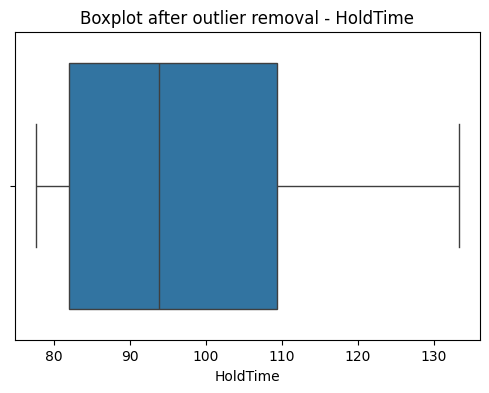

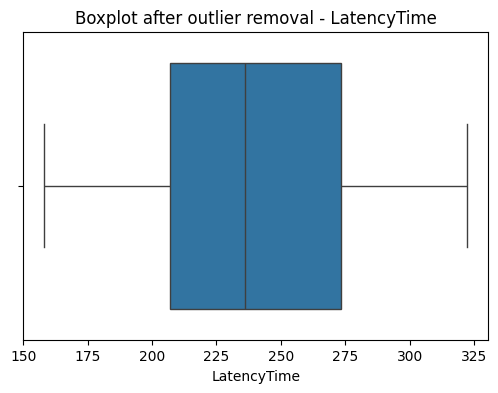

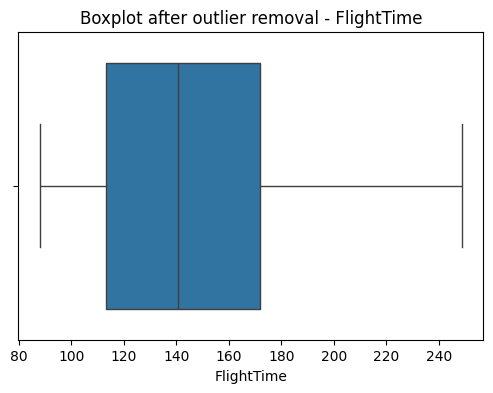

In [39]:
#Visulizing with box plots
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["HoldTime", "LatencyTime", "FlightTime"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot after outlier removal - {col}")
    plt.show()

In [40]:
num_columns

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']

In [41]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[  0.44029472  98.46899159   1.38804426 239.73266748 146.46105387]


In [42]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [43]:
#Visualizations 

import numpy as np


In [44]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,Gender_Male
18,0,78.1,0,289.1,195.3,True,False
25,0,130.9,0,220.7,175.8,True,False
26,1,85.9,3,257.8,171.9,False,True
32,0,78.1,0,226.6,132.8,True,True
33,0,117.2,2,171.9,93.8,False,True
...,...,...,...,...,...,...,...
5088257,1,109.4,3,312.5,218.8,True,False
5088273,0,93.8,2,218.8,125.0,True,True
5088276,1,78.1,3,265.6,187.5,False,True
5088284,1,109.4,1,296.9,203.1,True,False


In [45]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[ 78.1 130.9  85.9 117.2  93.8 101.6 109.4 121.1 105.5 118.2  97.7 113.3
 132.8 104.5  89.8  82.  125.   85.   83.  107.4 128.9  77.6  84.   86.9
  96.2 124.   80.1  87.9 111.3 115.2 103.5 112.8 103.  119.1  99.6  91.8
  95.7  91.3 122.9  81.   97.2 112.  121.8 120.1  95.  114.3 123.  129.
  78.  102.1  79.1  80.   89.   81.1  77.9  93.  127.9 129.9  94.   80.6
 127.  131.8 108.  100.  132.  108.4 106.  117.9  95.9 122.1 111.8 109.
  90.8  92.8 111.9 116.2 116.  100.1 104.  110.4  91.1  88.   87.   94.7
  92.9  85.1  94.2  88.9 102.5 112.3  86.   96.7 112.1 116.9 101.  110.
 100.6 108.9  98.6  92.   88.1 118.  121.   89.4 131.   79.6  87.2  79.8
 133.3 106.9 105.   93.3  96.   97.   95.2 120.  126.  110.1 107.2  99.1
  96.1  90.9  90.3 102.  114.  133.   86.2 117.  106.4 128.2 115.7 130.1
 119.9  90.  101.1 112.9 113.  109.9  98.1  98.9 102.9  81.8 107.9 118.7
 133.1  97.9 101.8  81.5 110.8 113.8 116.1 123.8  79.  111.  127.2 132.3
  96.9 116.7 115.  130.  107.1 1

In [46]:
park_scaled = df["Parkinsons"]

In [47]:
park_scaled.isna().sum()

0

In [48]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

In [49]:
#plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
#sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
#plt.show()

Heatmap Correlations

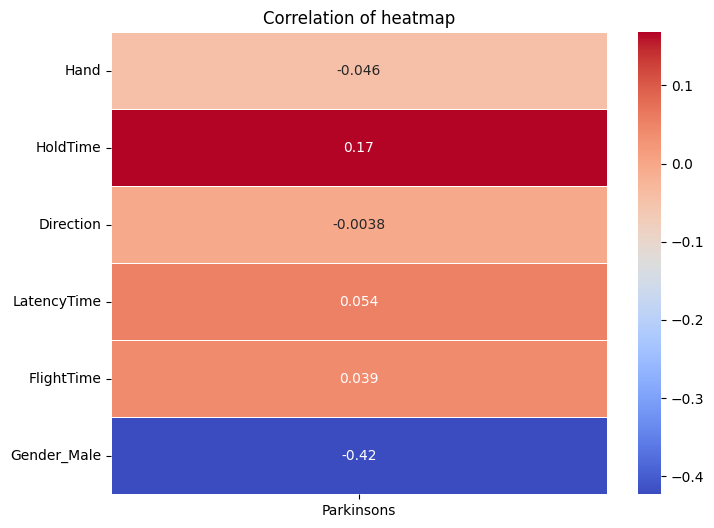

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

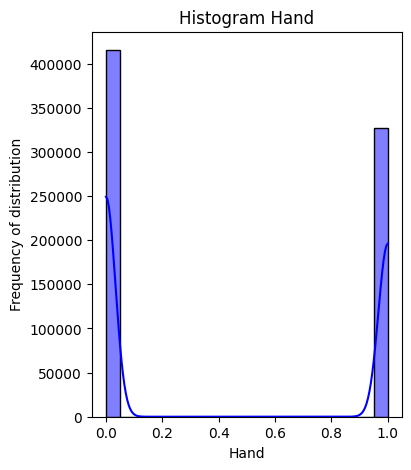

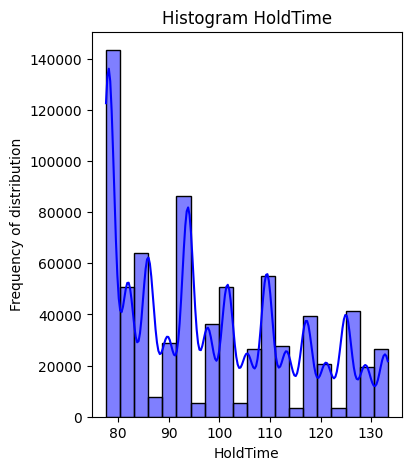

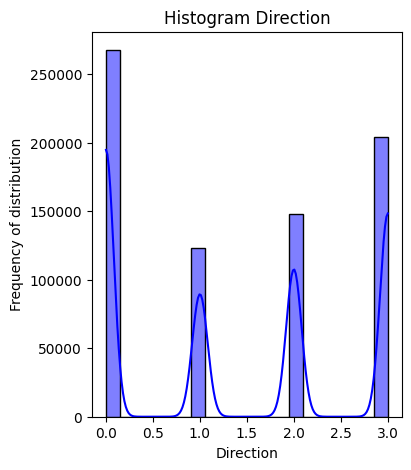

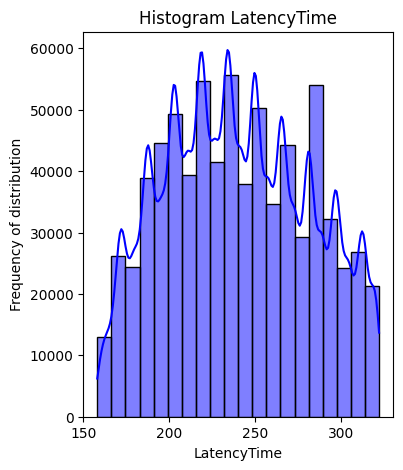

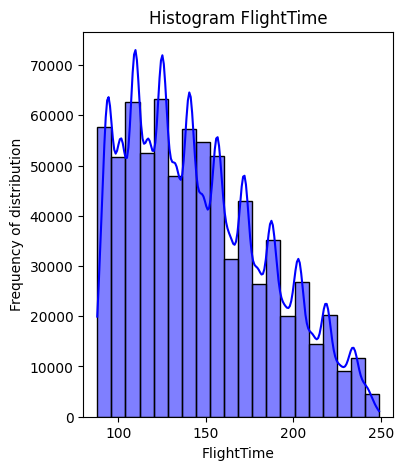

In [51]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [52]:
len(num_columns)
print(num_columns)

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime']


In [53]:
#Creating a dataframe with the scaled data and visualizing it again
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime
0,-0.886935,-1.215000,-1.130382,1.187889,1.261341
1,-0.886935,1.934492,-1.130382,-0.457969,0.757723
2,1.127478,-0.749734,1.312729,0.434741,0.657000
3,-0.886935,-1.215000,-1.130382,-0.316002,-0.352818
4,-0.886935,1.117295,0.498359,-1.632207,-1.360053
...,...,...,...,...,...
742400,1.127478,0.652029,1.312729,1.750946,1.868264
742401,-0.886935,-0.278503,0.498359,-0.503687,-0.554265
742402,1.127478,-1.215000,1.312729,0.622426,1.059894
742403,1.127478,0.652029,-0.316012,1.375575,1.462788


Histogram visualizations

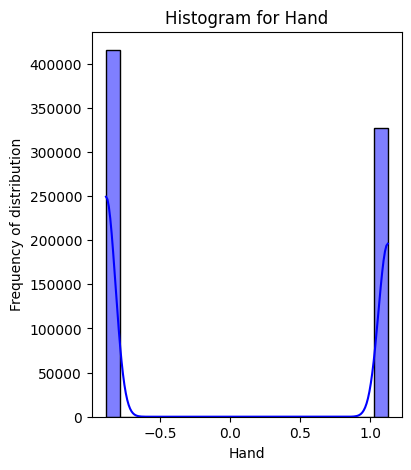

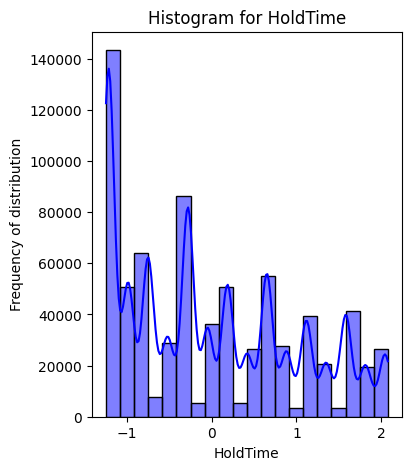

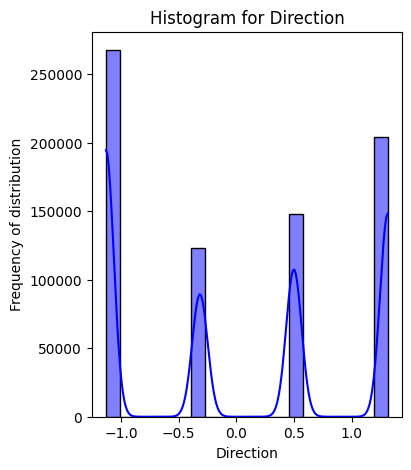

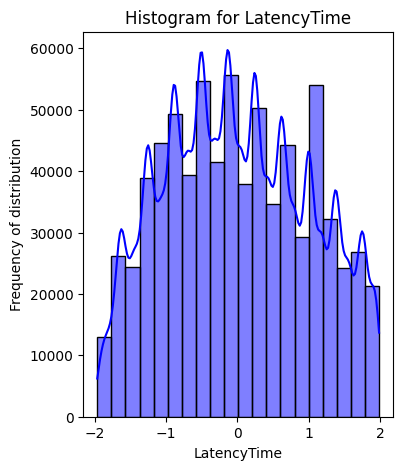

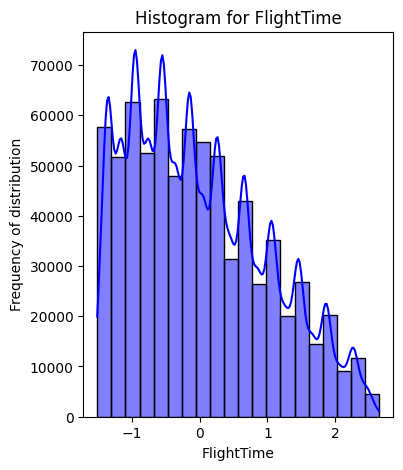

In [54]:
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

Heatmap Visualizations

In [55]:
df_scaled["Parkinsons"] = park_scaled.reset_index(drop=True)

In [56]:
df_scaled["Parkinsons"].isna().sum()

0

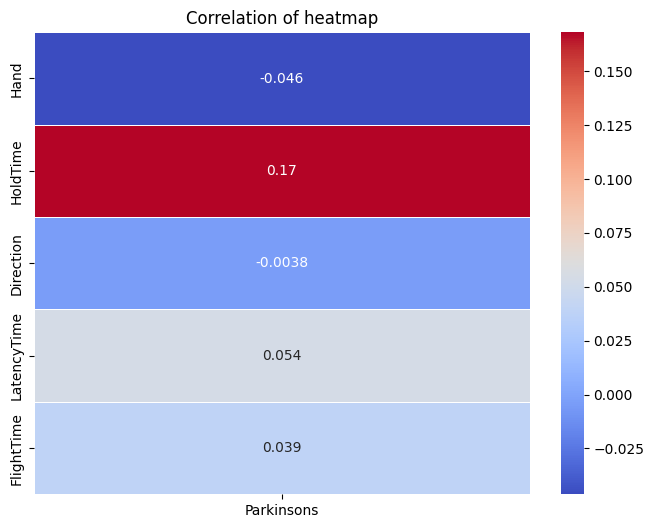

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


In [58]:
#Exporting this in the file directory for storage for a neural network

df_scaled.to_csv("nn.csv", index=False)